In [1]:
import pandas as pd

In [7]:
def read_dfs(path,file_name):
    dfs = []
    for year in range(2013,2024):
        temp = pd.read_csv(f'{path}/{file_name}_{year}.csv').drop('Unnamed: 0',axis=1)
        temp['year']=year
        dfs.append(temp)
    df = pd.concat(dfs,ignore_index=True)
    return df

In [8]:
path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project/dataset'
file_name = 'PROV_TYPE'

df = read_dfs(path,file_name)
df

,Rndrng_NPI,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,...,Drug_Tot_HCPCS_Cds.1,Med_Tot_Benes,Med_Tot_Srvcs,Med_Sbmtd_Chrg,Med_Mdcr_Alowd_Amt,Med_Mdcr_Pymt_Amt,Med_Mdcr_Stdzd_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,year
0,1003000126,I,MD,PrimaryCare,Y,22,665,1648.0,395335.00,146521.84,...,0.0,665.0,1648.0,395335.0,146521.84,116332.66,118271.40,74,2.1114,2013
1,1003000134,I,IL,LabPathology,Y,13,3939,7517.0,1211425.00,282079.49,...,0.0,3939.0,7517.0,1211425.0,282079.49,217960.62,211192.64,76,1.0156,2013
2,1003000142,I,OH,Anesthesia,Y,42,144,661.0,197224.00,63334.30,...,0.0,144.0,661.0,197224.0,63334.30,49752.77,49842.83,63,1.5662,2013
3,1003000407,I,PA,PrimaryCare,Y,37,436,1683.0,240818.00,174786.95,...,0.0,436.0,1683.0,240818.0,174786.95,138741.21,143708.38,76,1.8967,2013
4,1003000423,I,OH,OBGYN,Y,33,63,320.0,31637.00,13176.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56,1.1882,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12232189,1992999569,I,CA,VisionHearing,Y,6,16,24.0,3380.00,3010.25,...,0.0,16.0,24.0,3380.0,3010.25,1588.78,1269.53,72,0.8738,2023
12232190,1992999775,O,OR,FacilitySupplierProgram,Y,24,228,317.0,2682450.00,1076800.05,...,0.0,228.0,317.0,2682450.0,1076800.05,856134.21,798167.83,74,0.9921,2023
12232191,1992999817,I,CA,SurgeryOther,Y,13,18,44.0,21574.18,7201.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71,0.7118,2023
12232192,1992999825,I,WA,SurgeryOther,Y,34,405,646.0,235765.00,91260.38,...,0.0,405.0,646.0,235765.0,91260.38,69628.19,61665.04,77,1.0682,2023


In [9]:
df.to_csv(f'{path}/PROV_ALL_10_YEARS.csv')

In [ ]:
nan_count = df.isna().sum(axis=1) # Count NaNs per row
nan_count.value_counts() 

2     10897678
14     1334516
Name: count, dtype: int64

In [19]:
nan_cols_per_row = df.isna().apply(lambda r: r.index[r].tolist(), axis=1)
nan_cols_per_row

0                             [Drug_Sprsn_Ind, Med_Sprsn_Ind]
1                             [Drug_Sprsn_Ind, Med_Sprsn_Ind]
2                             [Drug_Sprsn_Ind, Med_Sprsn_Ind]
3                             [Drug_Sprsn_Ind, Med_Sprsn_Ind]
4           [Drug_Tot_HCPCS_Cds, Drug_Tot_Benes, Drug_Tot_...
                                  ...                        
12232189                      [Drug_Sprsn_Ind, Med_Sprsn_Ind]
12232190                      [Drug_Sprsn_Ind, Med_Sprsn_Ind]
12232191    [Drug_Tot_HCPCS_Cds, Drug_Tot_Benes, Drug_Tot_...
12232192                      [Drug_Sprsn_Ind, Med_Sprsn_Ind]
12232193                      [Drug_Sprsn_Ind, Med_Sprsn_Ind]
Length: 12232194, dtype: object

In [28]:
nan_cols_per_row

,index,missing_columns
0,0,"[Drug_Sprsn_Ind, Med_Sprsn_Ind]"
1,1,"[Drug_Sprsn_Ind, Med_Sprsn_Ind]"
2,2,"[Drug_Sprsn_Ind, Med_Sprsn_Ind]"
3,3,"[Drug_Sprsn_Ind, Med_Sprsn_Ind]"
4,4,"[Drug_Tot_HCPCS_Cds, Drug_Tot_Benes, Drug_Tot_..."
...,...,...
12232189,12232189,"[Drug_Sprsn_Ind, Med_Sprsn_Ind]"
12232190,12232190,"[Drug_Sprsn_Ind, Med_Sprsn_Ind]"
12232191,12232191,"[Drug_Tot_HCPCS_Cds, Drug_Tot_Benes, Drug_Tot_..."
12232192,12232192,"[Drug_Sprsn_Ind, Med_Sprsn_Ind]"


In [33]:
nan_cols_per_row['missing_columns'] = nan_cols_per_row['missing_columns'].astype(str)
nan_cols_per_row

,index,missing_columns
0,0,"['Drug_Sprsn_Ind', 'Med_Sprsn_Ind']"
1,1,"['Drug_Sprsn_Ind', 'Med_Sprsn_Ind']"
2,2,"['Drug_Sprsn_Ind', 'Med_Sprsn_Ind']"
3,3,"['Drug_Sprsn_Ind', 'Med_Sprsn_Ind']"
4,4,"['Drug_Tot_HCPCS_Cds', 'Drug_Tot_Benes', 'Drug..."
...,...,...
12232189,12232189,"['Drug_Sprsn_Ind', 'Med_Sprsn_Ind']"
12232190,12232190,"['Drug_Sprsn_Ind', 'Med_Sprsn_Ind']"
12232191,12232191,"['Drug_Tot_HCPCS_Cds', 'Drug_Tot_Benes', 'Drug..."
12232192,12232192,"['Drug_Sprsn_Ind', 'Med_Sprsn_Ind']"


In [35]:
missing_cols = nan_cols_per_row.groupby('missing_columns').size().rename('missing_num_rows').reset_index()
missing_cols

,missing_columns,missing_num_rows
0,"['Drug_Sprsn_Ind', 'Med_Sprsn_Ind']",10897678
1,"['Drug_Tot_HCPCS_Cds', 'Drug_Tot_Benes', 'Drug...",1334516


In [43]:
print('total rows has missing data = total rows of data : ', sum(missing_cols['missing_num_rows']) == df.shape[0])

print(missing_cols.loc[1,'missing_columns'])

#print('are all Drug_Suppress_Indicator and Medical_Suppress_Indicator missing?', flag)

total rows has missing data = total rows of data :  True
['Drug_Tot_HCPCS_Cds', 'Drug_Tot_Benes', 'Drug_Tot_Srvcs', 'Drug_Sbmtd_Chrg', 'Drug_Mdcr_Alowd_Amt', 'Drug_Mdcr_Pymt_Amt', 'Drug_Mdcr_Stdzd_Amt', 'Drug_Tot_HCPCS_Cds.1', 'Med_Tot_Benes', 'Med_Tot_Srvcs', 'Med_Sbmtd_Chrg', 'Med_Mdcr_Alowd_Amt', 'Med_Mdcr_Pymt_Amt', 'Med_Mdcr_Stdzd_Amt']


In [50]:
pd.set_option("display.max_columns", None)  # show all columns

In [ ]:
mask =  df.isna().sum(axis=1)==2
df[mask].to_csv(f'{path}/PROV_NON')

,Rndrng_NPI,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt,Drug_Sprsn_Ind,Drug_Tot_HCPCS_Cds,Drug_Tot_Benes,Drug_Tot_Srvcs,Drug_Sbmtd_Chrg,Drug_Mdcr_Alowd_Amt,Drug_Mdcr_Pymt_Amt,Drug_Mdcr_Stdzd_Amt,Med_Sprsn_Ind,Drug_Tot_HCPCS_Cds.1,Med_Tot_Benes,Med_Tot_Srvcs,Med_Sbmtd_Chrg,Med_Mdcr_Alowd_Amt,Med_Mdcr_Pymt_Amt,Med_Mdcr_Stdzd_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,year
0,1003000126,I,MD,PrimaryCare,Y,22,665,1648.0,395335.0,146521.84,116332.66,118271.40,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,665.0,1648.0,395335.0,146521.84,116332.66,118271.40,74,2.1114,2013
1,1003000134,I,IL,LabPathology,Y,13,3939,7517.0,1211425.0,282079.49,217960.62,211192.64,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,3939.0,7517.0,1211425.0,282079.49,217960.62,211192.64,76,1.0156,2013
2,1003000142,I,OH,Anesthesia,Y,42,144,661.0,197224.0,63334.30,49752.77,49842.83,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,144.0,661.0,197224.0,63334.30,49752.77,49842.83,63,1.5662,2013
3,1003000407,I,PA,PrimaryCare,Y,37,436,1683.0,240818.0,174786.95,138741.21,143708.38,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,436.0,1683.0,240818.0,174786.95,138741.21,143708.38,76,1.8967,2013
5,1003000480,I,CO,SurgeryOther,Y,60,146,252.0,338191.0,66294.38,51955.64,54552.21,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,146.0,252.0,338191.0,66294.38,51955.64,54552.21,63,2.1587,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12232188,1992999551,I,CA,PrimaryCare,Y,51,199,1208.0,162476.0,91963.29,69136.34,63922.25,NaN,6.0,50.0,456.0,24543.0,15093.46,13371.36,13359.19,NaN,6.0,199.0,752.0,137933.0,76869.83,55764.98,50563.06,77,0.9606,2023
12232189,1992999569,I,CA,VisionHearing,Y,6,16,24.0,3380.0,3010.25,1588.78,1269.53,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,16.0,24.0,3380.0,3010.25,1588.78,1269.53,72,0.8738,2023
12232190,1992999775,O,OR,FacilitySupplierProgram,Y,24,228,317.0,2682450.0,1076800.05,856134.21,798167.83,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,228.0,317.0,2682450.0,1076800.05,856134.21,798167.83,74,0.9921,2023
12232192,1992999825,I,WA,SurgeryOther,Y,34,405,646.0,235765.0,91260.38,69628.19,61665.04,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,405.0,646.0,235765.0,91260.38,69628.19,61665.04,77,1.0682,2023


In [59]:
mask =  df.isna().sum(axis=1)==14
df[mask].groupby('Rndrng_Prvdr_Type').size()

Rndrng_Prvdr_Type
APP                        418008
AcuteCare                   27582
Anesthesia                   7283
BehavioralHealth             7224
CardioVascularSurgery        3728
Cardiology                  39368
FacilitySupplierProgram     12165
LabPathology                  802
MedicalSpecialtyOther      203069
OBGYN                       78946
OncologyHeme                16615
PharmacyNutrition            1183
PrimaryCare                283214
RadiologyImaging            36716
RehabTherapy                17257
SurgeryOther               146473
UnknownOther                  350
VisionHearing               34533
dtype: int64

In [63]:
mask = (df['Drug_Sprsn_Ind']=='*') & (df['Med_Sprsn_Ind']=='*')
df[mask]

,Rndrng_NPI,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt,Drug_Sprsn_Ind,Drug_Tot_HCPCS_Cds,Drug_Tot_Benes,Drug_Tot_Srvcs,Drug_Sbmtd_Chrg,Drug_Mdcr_Alowd_Amt,Drug_Mdcr_Pymt_Amt,Drug_Mdcr_Stdzd_Amt,Med_Sprsn_Ind,Drug_Tot_HCPCS_Cds.1,Med_Tot_Benes,Med_Tot_Srvcs,Med_Sbmtd_Chrg,Med_Mdcr_Alowd_Amt,Med_Mdcr_Pymt_Amt,Med_Mdcr_Stdzd_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,year
24458,1023112471,I,WA,APP,Y,7,11,20.0,693.50,198.34,196.86,210.87,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62,0.9092,2013
54827,1053500900,I,KY,APP,Y,5,11,944.0,2150.00,1073.41,855.25,869.85,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66,0.9955,2013
82124,1083721518,I,TX,APP,Y,8,11,13.0,1351.00,698.41,471.40,619.58,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56,2.2611,2013
83901,1083811954,I,AZ,PrimaryCare,Y,7,11,14.0,387.21,82.50,76.38,78.47,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66,0.9456,2013
92946,1093841249,I,MD,APP,Y,9,11,35.0,1290.40,880.63,624.48,758.23,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67,0.8895,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12160889,1942373097,I,FL,APP,Y,10,11,21.0,864.03,191.89,142.60,148.39,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66,0.9511,2023
12186674,1962502153,I,AZ,MedicalSpecialtyOther,Y,4,11,17.0,1190.84,770.62,729.57,683.94,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78,1.2597,2023
12187323,1962543397,I,CA,PrimaryCare,Y,22,11,999.0,45279.10,3347.81,2431.08,2289.90,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65,1.1708,2023
12201387,1972655389,I,CA,APP,Y,6,11,22.0,18053.72,3171.44,2261.03,2160.11,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,1.5342,2023


In [61]:
mask = (df['Drug_Sprsn_Ind']=='*') & (df['Med_Sprsn_Ind']=='#')
df[mask].groupby('Rndrng_Prvdr_Type').size()

Rndrng_Prvdr_Type
APP                        417358
AcuteCare                   27564
Anesthesia                   7278
BehavioralHealth             7216
CardioVascularSurgery        3728
Cardiology                  39366
FacilitySupplierProgram     11013
LabPathology                  801
MedicalSpecialtyOther      202997
OBGYN                       78911
OncologyHeme                16554
PharmacyNutrition            1097
PrimaryCare                282318
RadiologyImaging            36704
RehabTherapy                17244
SurgeryOther               146400
UnknownOther                  350
VisionHearing               34516
dtype: int64

In [62]:
mask = (df['Drug_Sprsn_Ind']=='#') & (df['Med_Sprsn_Ind']=='*')
df[mask].groupby('Rndrng_Prvdr_Type').size()

Rndrng_Prvdr_Type
APP                         130
AcuteCare                     3
Anesthesia                    2
BehavioralHealth              4
Cardiology                    2
FacilitySupplierProgram    1112
MedicalSpecialtyOther         7
OBGYN                         3
OncologyHeme                  7
PharmacyNutrition            76
PrimaryCare                 143
RadiologyImaging              6
RehabTherapy                  1
SurgeryOther                  7
VisionHearing                 3
dtype: int64

In [58]:
mask = (df['Drug_Sprsn_Ind']=='#') & (df['Med_Sprsn_Ind']=='#')
df[mask]

,Rndrng_NPI,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt,Drug_Sprsn_Ind,Drug_Tot_HCPCS_Cds,Drug_Tot_Benes,Drug_Tot_Srvcs,Drug_Sbmtd_Chrg,Drug_Mdcr_Alowd_Amt,Drug_Mdcr_Pymt_Amt,Drug_Mdcr_Stdzd_Amt,Med_Sprsn_Ind,Drug_Tot_HCPCS_Cds.1,Med_Tot_Benes,Med_Tot_Srvcs,Med_Sbmtd_Chrg,Med_Mdcr_Alowd_Amt,Med_Mdcr_Pymt_Amt,Med_Mdcr_Stdzd_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,year


In [66]:
all_available_cols = df.columns.tolist()
all_available_cols = [c for c in all_available_cols if c not in missing_cols.loc[1,'missing_columns']]
df1 = df[all_available_cols]
df1

,Rndrng_NPI,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt,Drug_Sprsn_Ind,Med_Sprsn_Ind,Bene_Avg_Age,Bene_Avg_Risk_Scre,year
0,1003000126,I,MD,PrimaryCare,Y,395335.00,146521.84,116332.66,118271.40,NaN,NaN,74,2.1114,2013
1,1003000134,I,IL,LabPathology,Y,1211425.00,282079.49,217960.62,211192.64,NaN,NaN,76,1.0156,2013
2,1003000142,I,OH,Anesthesia,Y,197224.00,63334.30,49752.77,49842.83,NaN,NaN,63,1.5662,2013
3,1003000407,I,PA,PrimaryCare,Y,240818.00,174786.95,138741.21,143708.38,NaN,NaN,76,1.8967,2013
4,1003000423,I,OH,OBGYN,Y,31637.00,13176.47,10320.43,10896.40,*,#,56,1.1882,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12232189,1992999569,I,CA,VisionHearing,Y,3380.00,3010.25,1588.78,1269.53,NaN,NaN,72,0.8738,2023
12232190,1992999775,O,OR,FacilitySupplierProgram,Y,2682450.00,1076800.05,856134.21,798167.83,NaN,NaN,74,0.9921,2023
12232191,1992999817,I,CA,SurgeryOther,Y,21574.18,7201.29,5600.89,5380.82,*,#,71,0.7118,2023
12232192,1992999825,I,WA,SurgeryOther,Y,235765.00,91260.38,69628.19,61665.04,NaN,NaN,77,1.0682,2023


# check distribution of total medicare/subcategory payments by year

In [82]:
import matplotlib.pyplot as plt

def plt_total_col_by_year(df,col):
    result_col = df.groupby('year')[col].sum()
    plt.figure(figsize=(8,5))
    plt.plot(result_col.index, result_col.values, marker="o", label=f"{col}")
    plt.title(f"National {col} Spending")
    plt.xlabel("Year")
    plt.ylabel("Total Spending")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return 


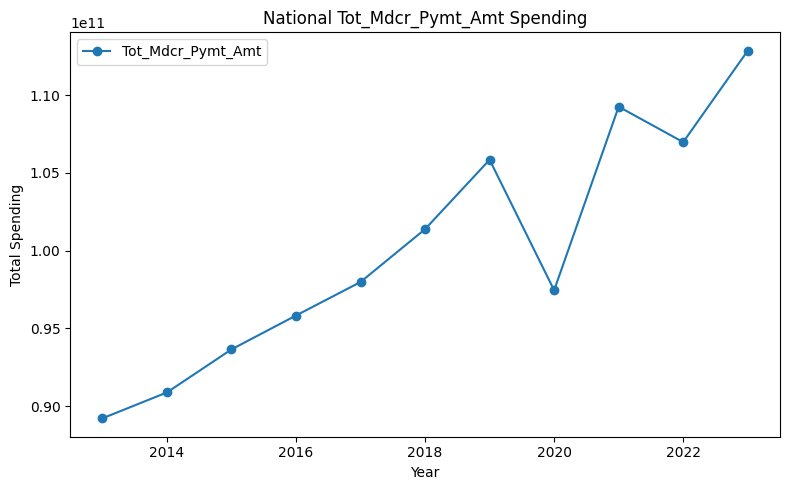

In [83]:
plt_total_col_by_year(df,'Tot_Mdcr_Pymt_Amt')

In [85]:
mask = df['Drug_Sprsn_Ind'].isna() & df['Med_Sprsn_Ind'].isna()
df_non_sprsn = df[mask]
df_non_sprsn

,Rndrng_NPI,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt,Drug_Sprsn_Ind,Drug_Tot_HCPCS_Cds,Drug_Tot_Benes,Drug_Tot_Srvcs,Drug_Sbmtd_Chrg,Drug_Mdcr_Alowd_Amt,Drug_Mdcr_Pymt_Amt,Drug_Mdcr_Stdzd_Amt,Med_Sprsn_Ind,Drug_Tot_HCPCS_Cds.1,Med_Tot_Benes,Med_Tot_Srvcs,Med_Sbmtd_Chrg,Med_Mdcr_Alowd_Amt,Med_Mdcr_Pymt_Amt,Med_Mdcr_Stdzd_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,year
0,1003000126,I,MD,PrimaryCare,Y,22,665,1648.0,395335.0,146521.84,116332.66,118271.40,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,665.0,1648.0,395335.0,146521.84,116332.66,118271.40,74,2.1114,2013
1,1003000134,I,IL,LabPathology,Y,13,3939,7517.0,1211425.0,282079.49,217960.62,211192.64,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,3939.0,7517.0,1211425.0,282079.49,217960.62,211192.64,76,1.0156,2013
2,1003000142,I,OH,Anesthesia,Y,42,144,661.0,197224.0,63334.30,49752.77,49842.83,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,144.0,661.0,197224.0,63334.30,49752.77,49842.83,63,1.5662,2013
3,1003000407,I,PA,PrimaryCare,Y,37,436,1683.0,240818.0,174786.95,138741.21,143708.38,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,436.0,1683.0,240818.0,174786.95,138741.21,143708.38,76,1.8967,2013
5,1003000480,I,CO,SurgeryOther,Y,60,146,252.0,338191.0,66294.38,51955.64,54552.21,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,146.0,252.0,338191.0,66294.38,51955.64,54552.21,63,2.1587,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12232188,1992999551,I,CA,PrimaryCare,Y,51,199,1208.0,162476.0,91963.29,69136.34,63922.25,NaN,6.0,50.0,456.0,24543.0,15093.46,13371.36,13359.19,NaN,6.0,199.0,752.0,137933.0,76869.83,55764.98,50563.06,77,0.9606,2023
12232189,1992999569,I,CA,VisionHearing,Y,6,16,24.0,3380.0,3010.25,1588.78,1269.53,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,16.0,24.0,3380.0,3010.25,1588.78,1269.53,72,0.8738,2023
12232190,1992999775,O,OR,FacilitySupplierProgram,Y,24,228,317.0,2682450.0,1076800.05,856134.21,798167.83,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,228.0,317.0,2682450.0,1076800.05,856134.21,798167.83,74,0.9921,2023
12232192,1992999825,I,WA,SurgeryOther,Y,34,405,646.0,235765.0,91260.38,69628.19,61665.04,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,0.0,405.0,646.0,235765.0,91260.38,69628.19,61665.04,77,1.0682,2023


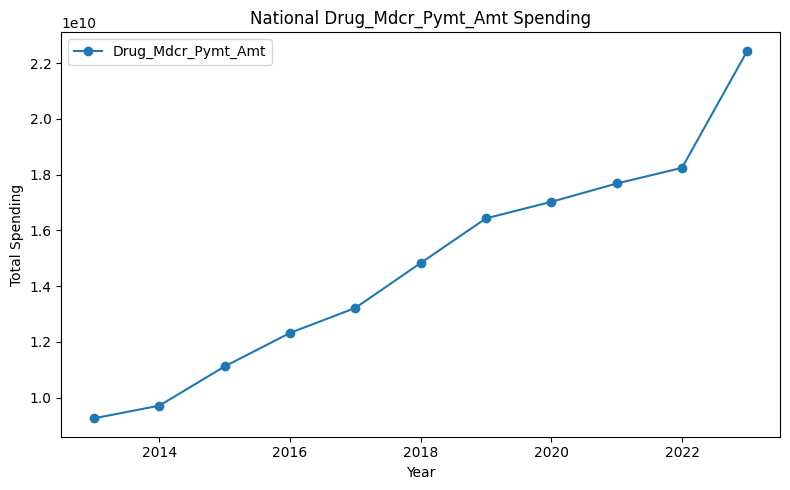

In [86]:
plt_total_col_by_year(df_non_sprsn,'Drug_Mdcr_Pymt_Amt')

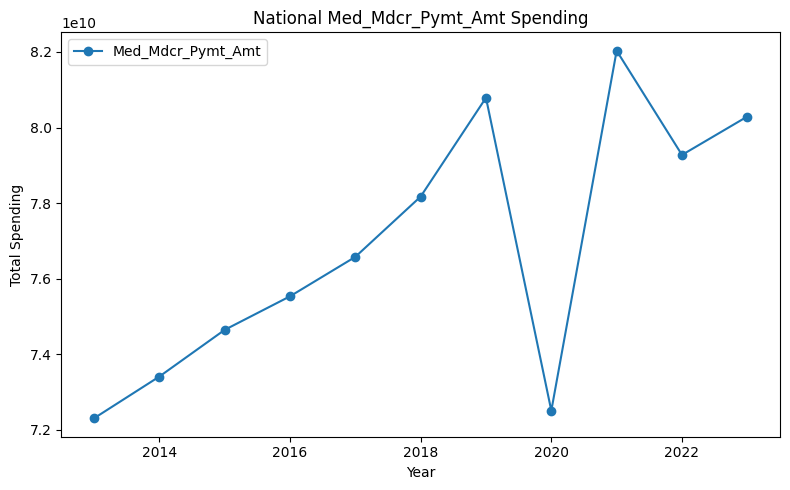

In [87]:
plt_total_col_by_year(df_non_sprsn,'Med_Mdcr_Pymt_Amt')

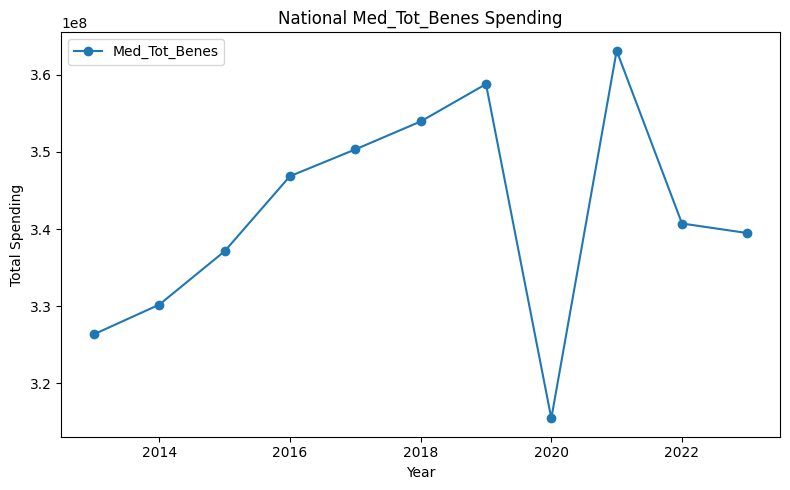

In [88]:
plt_total_col_by_year(df,'Med_Tot_Benes')

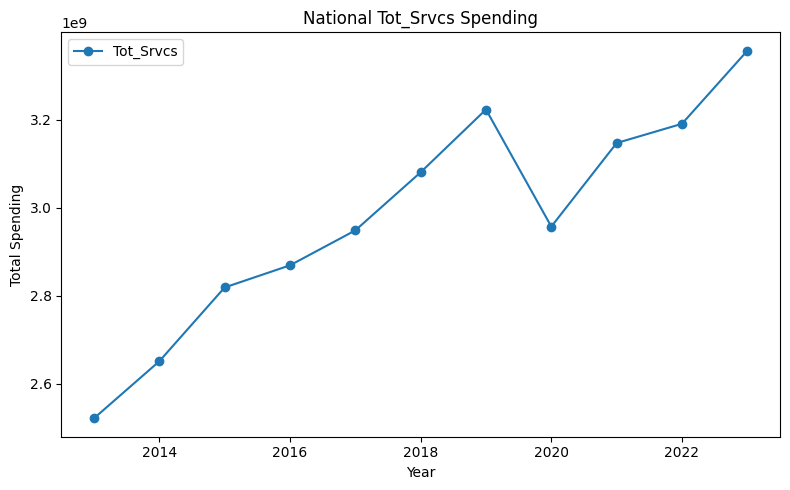

In [89]:
plt_total_col_by_year(df,'Tot_Srvcs')

In [ ]:
# Check state information

In [ ]:
sum(df['Rndrng_Prvdr_State_Abrvtn'].isna()) # nice, no missing data in state

0

In [91]:
df['Rndrng_Prvdr_State_Abrvtn'].value_counts()

Rndrng_Prvdr_State_Abrvtn
CA    985097
NY    854179
TX    784738
FL    761313
PA    614839
       ...  
MP       349
AA       123
AS        26
PW         5
FM         2
Name: count, Length: 63, dtype: int64